# Data Exploration

## Part 1: Computing mid-prices, returns, pre-averaging

Exploring EURUSD tick data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from methods.data_utils import load_data, pre_avg, \
    compute_returns, filter_day, summarize_data

from methods.plotting import set_style
set_style()  # defaults


### Import data

In [2]:
market = "EURUSD"
df_init = load_data(market=market)
print(len(df_init))
df_init.head()

1330124


,bid,ask,volume,mid_price
datetime,,,,
2026-02-01 22:00:00.410000+00:00,1.18492,1.18547,0,1.185195
2026-02-01 22:00:01.866000+00:00,1.18497,1.18543,0,1.185200
2026-02-01 22:00:06.535000+00:00,1.18499,1.18544,0,1.185215
2026-02-01 22:00:10.246000+00:00,1.18499,1.18539,0,1.185190
2026-02-01 22:00:48.466000+00:00,1.18499,1.18537,0,1.185180


### Pre-averaging and compute returns

In [3]:
k = 10 # Pre-average over k ticks

# Pre-averaging over k ticks, and computing returns:
df = pre_avg(df=df_init, tick = True, k=k) 
df = compute_returns(df)
print(len(df))
df.head()


133012


,bid,ask,volume,mid_price,pre_avg,r
datetime,,,,,,
2026-02-01 22:05:10.359000+00:00,1.18499,1.18537,0,1.185180,1.185218,-0.000004
2026-02-01 22:10:28.993000+00:00,1.18505,1.18535,0,1.185200,1.185177,-0.000041
2026-02-01 22:12:13.345000+00:00,1.18509,1.18534,0,1.185215,1.185159,-0.000019
2026-02-01 22:14:45.050000+00:00,1.18508,1.18519,0,1.185135,1.185171,0.000012
2026-02-01 22:15:30.484000+00:00,1.18494,1.18523,0,1.185085,1.185107,-0.000063


### Plotting raw vs pre-averaged prices

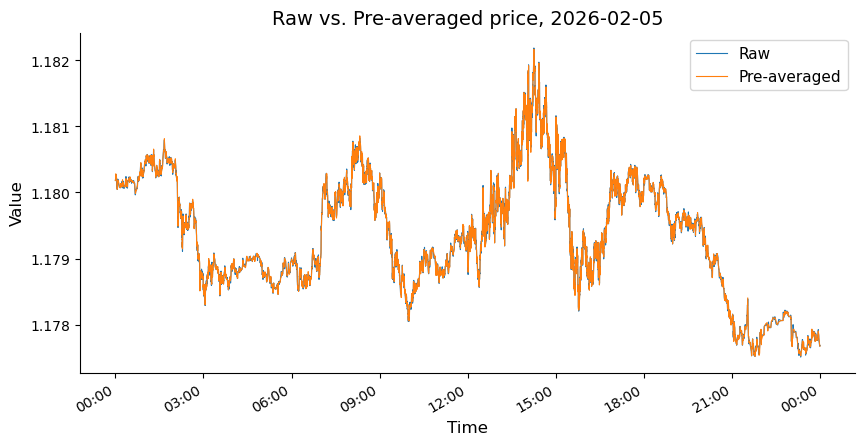

In [4]:
# Choose a day:
day = "2026-02-05"
df_day = filter_day(df, day=day)

plt.plot(df_day.index, df_day["mid_price"], label = "Raw")
plt.plot(df_day.index, df_day["pre_avg"], label = "Pre-averaged")
plt.title(f"Raw vs. Pre-averaged price, {day}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.gcf().autofmt_xdate()  # rotates labels so they don't overlap
plt.legend()
plt.savefig(f"../plots/raw_vs_preavg_{day}.pdf", bbox_inches="tight", format="pdf")



### Plotting Pre-averaged Mid Prices for february

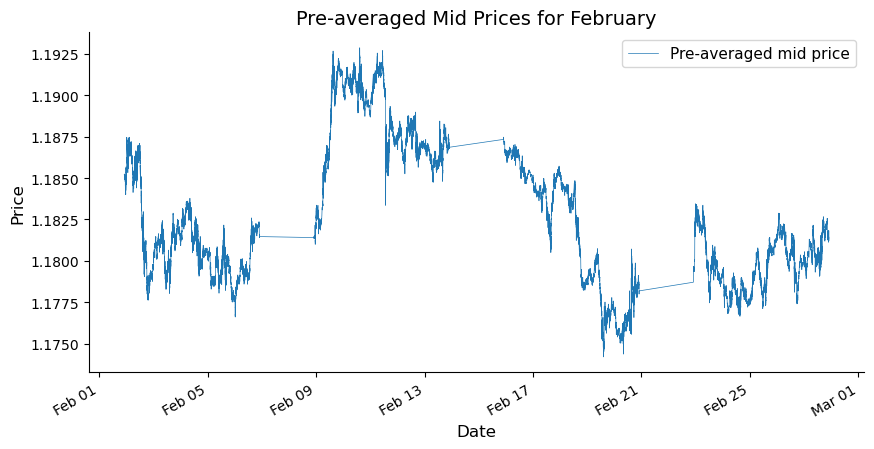

In [5]:
plt.plot(df.index, df["pre_avg"], lw=0.5, label="Pre-averaged mid price")
plt.title("Pre-averaged Mid Prices for February")
plt.xlabel("Date")
plt.ylabel("Price")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.gcf().autofmt_xdate()
plt.legend()
plt.savefig("../plots/preavg_february.pdf", bbox_inches="tight", format="pdf")


## Part 2: Comparing markets

### Loading data for 4 markets

In [6]:
markets = ["EURUSD", "USDJPY", "USDZAR", "XAUUSD"]

eurusd = load_data(market = markets[0])
usdjpy = load_data(market = markets[1])
usdzar = load_data(market = markets[2])
xauusd = load_data(market = markets[3])

data = {"EURUSD": eurusd, 
        "USDJPY": usdjpy, 
        "USDZAR": usdzar, 
        "XAUUSD": xauusd}

for name, df in data.items():
    print(name)
    print("start:", df.index.min())
    print("end:", df.index.max())
    print("ticks:", len(df))
    print()

EURUSD
start: 2026-02-01 22:00:00.410000+00:00
end: 2026-02-27 21:59:59.033000+00:00
ticks: 1330124

USDJPY
start: 2026-02-01 22:00:01.917000+00:00
end: 2026-02-27 21:59:59.135000+00:00
ticks: 1994068

USDZAR
start: 2026-02-01 22:00:19.318000+00:00
end: 2026-02-27 21:59:59.090000+00:00
ticks: 3231325

XAUUSD
start: 2026-02-01 23:06:26.655000+00:00
end: 2026-02-27 21:59:59.799000+00:00
ticks: 7538339



### Plotting histogram, time between ticks

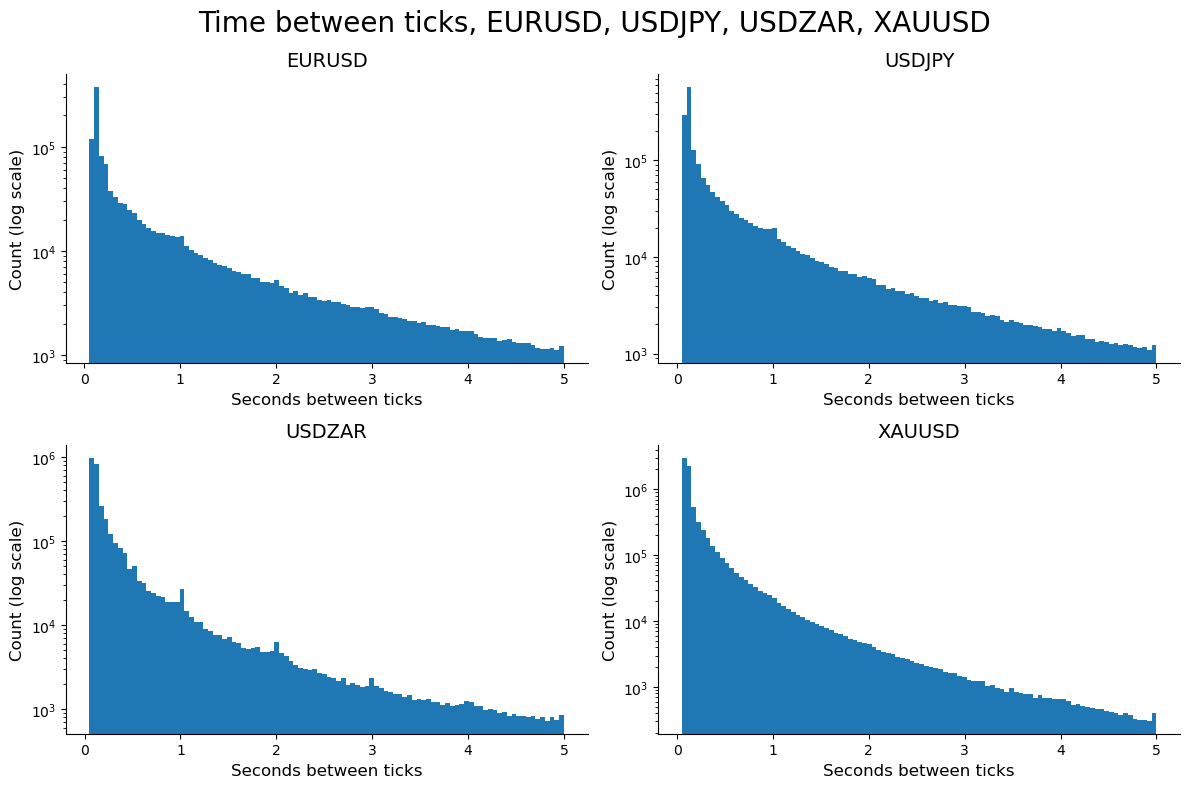

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, df) in zip(axes, data.items()):
    
    dt = df.index.to_series().diff().dt.total_seconds()
    dt = dt[dt < 5]
    
    ax.hist(dt, bins=100)
    ax.set_yscale("log")
    ax.set_title(name)
    ax.set_xlabel("Seconds between ticks")
    ax.set_ylabel("Count (log scale)")

fig.suptitle("Time between ticks, EURUSD, USDJPY, USDZAR, XAUUSD", fontsize=20)
plt.tight_layout()

plt.savefig("../plots/time_between_ticks_markets.pdf", bbox_inches="tight", format="pdf")
plt.show()

### Spread for a given day

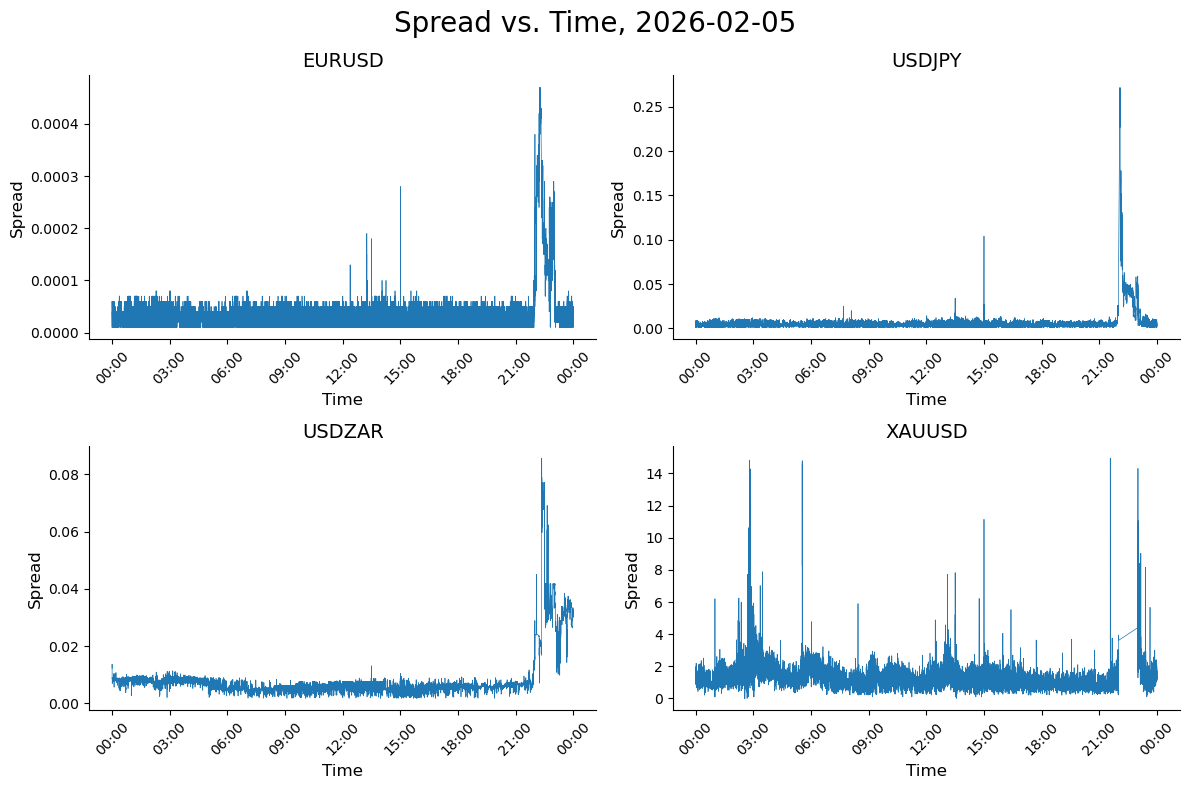

In [8]:
day = "2026-02-05"

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, df_m) in zip(axes, data.items()):
    df_day = filter_day(df_m, day=day).copy()
    df_day["spread"] = df_day["ask"] - df_day["bid"]

    ax.plot(df_day.index, df_day["spread"], lw=0.5)
    ax.set_title(name)
    ax.set_xlabel("Time")
    ax.set_ylabel("Spread")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.tick_params(axis="x", rotation=45)

fig.suptitle(f"Spread vs. Time, {day}", fontsize=20)
plt.tight_layout()
plt.savefig(f"../plots/spread_{day}_all_markets.pdf", bbox_inches="tight")
plt.show()


### Distribution of Spread

log-scaled

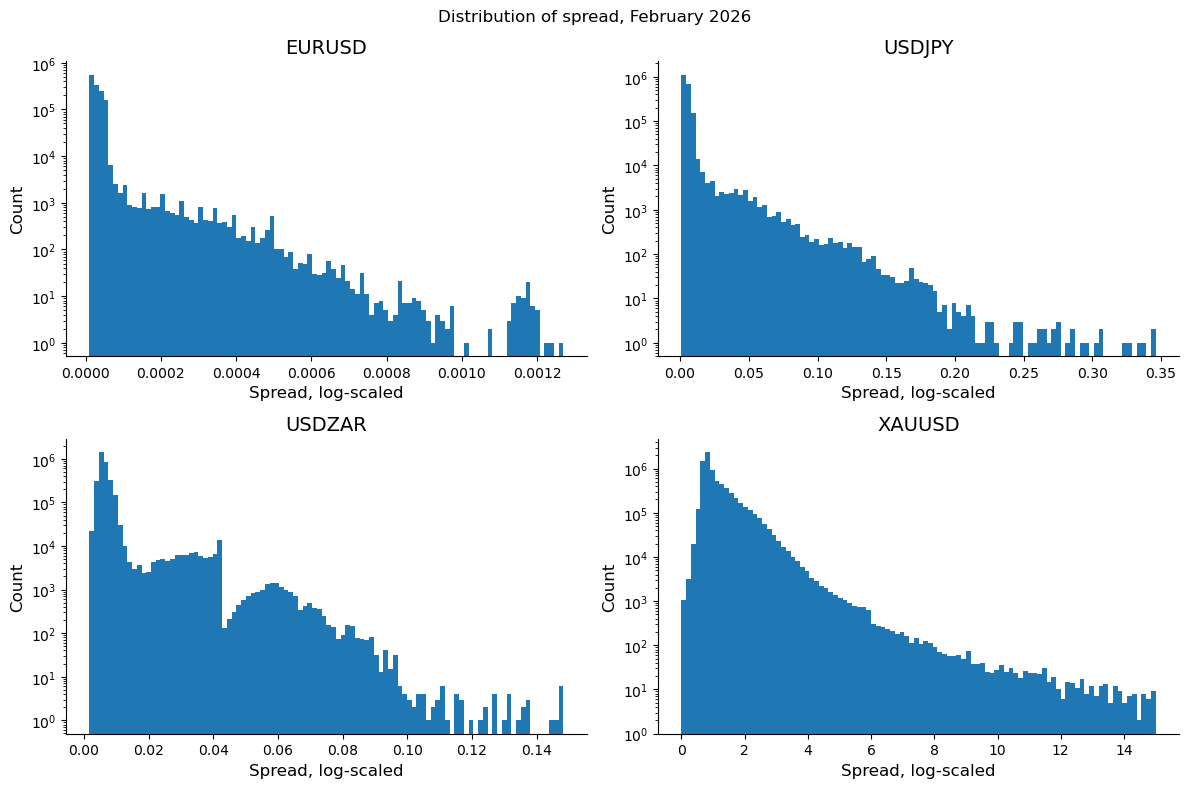

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, df_m) in zip(axes, data.items()):
    spread = df_m["ask"] - df_m["bid"]

    ax.hist(spread, bins=100)
    ax.set_title(name)
    ax.set_xlabel("Spread, log-scaled")
    ax.set_ylabel("Count")
    ax.set_yscale("log")

fig.suptitle(f"Distribution of spread, February 2026")
plt.tight_layout()
plt.savefig("../plots/spread_distributio_all_markets.pdf", bbox_inches="tight")
plt.show()


### Plotting AutoCorrelationFactor ACF in returns

KeyboardInterrupt: 

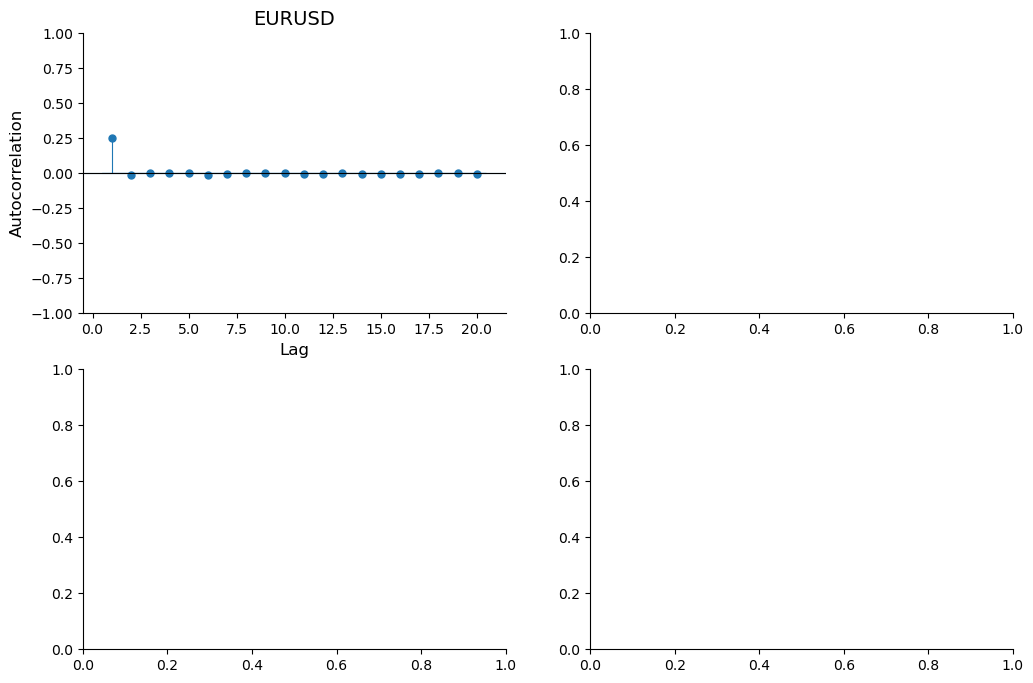

In [10]:
import statsmodels.api as sm

data_processed = {}
for name, df_m in data.items():
    df_m = pre_avg(df=df_m, tick=True, k=k)
    df_m = compute_returns(df_m)
    data_processed[name] = df_m


fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, df_m) in zip(axes, data_processed.items()):
    r = df_m["r"].dropna().iloc[:200000]  # sample for speed

    sm.graphics.tsa.plot_acf(r, lags=20, ax=ax, zero=False)

    ax.set_title(name)
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")
    ax.axhline(0, color="black", linewidth=0.8)

fig.suptitle("ACF of tick returns, lags 1–20 (February 2026)")
plt.tight_layout()
plt.savefig("../plots/acf_returns_all_markets.pdf", bbox_inches="tight")
plt.show()
